In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
import numpy as np
import torch
import os
import networkx as nx
from matplotlib.ticker import MultipleLocator


In [1]:
plt.style.use('seaborn-v0_8-paper')  # 更改图表风格

default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# 打印默认颜色数组
print(default_colors)

NameError: name 'plt' is not defined

tensor([0.1166, 0.6358, 0.8274, 0.8731, 0.8931, 0.9032, 0.9124, 0.9197, 0.9262,
        0.9265, 0.9232, 0.9346, 0.9373, 0.9301, 0.9425, 0.9411, 0.9425, 0.9483,
        0.9500, 0.9491, 0.9500, 0.9521, 0.9495, 0.9572, 0.9583, 0.9567, 0.9569,
        0.9545, 0.9583, 0.9608, 0.9621, 0.9635, 0.9624, 0.9614, 0.9637, 0.9646,
        0.9633, 0.9647, 0.9654, 0.9661, 0.9670, 0.9671, 0.9670, 0.9663, 0.9673,
        0.9676, 0.9682, 0.9676, 0.9679, 0.9693, 0.9686, 0.9681, 0.9694, 0.9690,
        0.9689, 0.9694, 0.9695, 0.9698, 0.9698, 0.9705, 0.9700, 0.9700, 0.9698,
        0.9709, 0.9706, 0.9701, 0.9705, 0.9709, 0.9703, 0.9709, 0.9710, 0.9707,
        0.9718, 0.9712, 0.9715, 0.9718, 0.9719, 0.9725, 0.9718, 0.9721, 0.9724,
        0.9725, 0.9723, 0.9727, 0.9726, 0.9724, 0.9722, 0.9731, 0.9729, 0.9725,
        0.9728, 0.9738, 0.9732, 0.9733, 0.9731, 0.9738, 0.9735, 0.9738, 0.9741,
        0.9738, 0.9737], dtype=torch.float64)

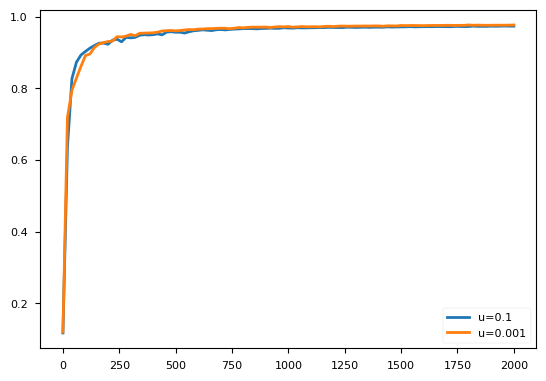

In [20]:
result_0001=torch.load("../results/2024-09-15_19-32_dist_mnist_sonata_mu/sonata_results.pt",map_location=torch.device("cpu"))
mean_001=torch.mean(torch.stack(result_0001["top1_accuracy"]), dim=1)
plt.plot(np.arange(mean_acc_2.shape[0]) * 20,mean_acc_2,zorder=3,linewidth=2,label="u=0.1")
plt.plot(np.arange(mean_001.shape[0]) * 20,mean_001,zorder=3,linewidth=2,label="u=0.001")
plt.legend()
mean_acc_2


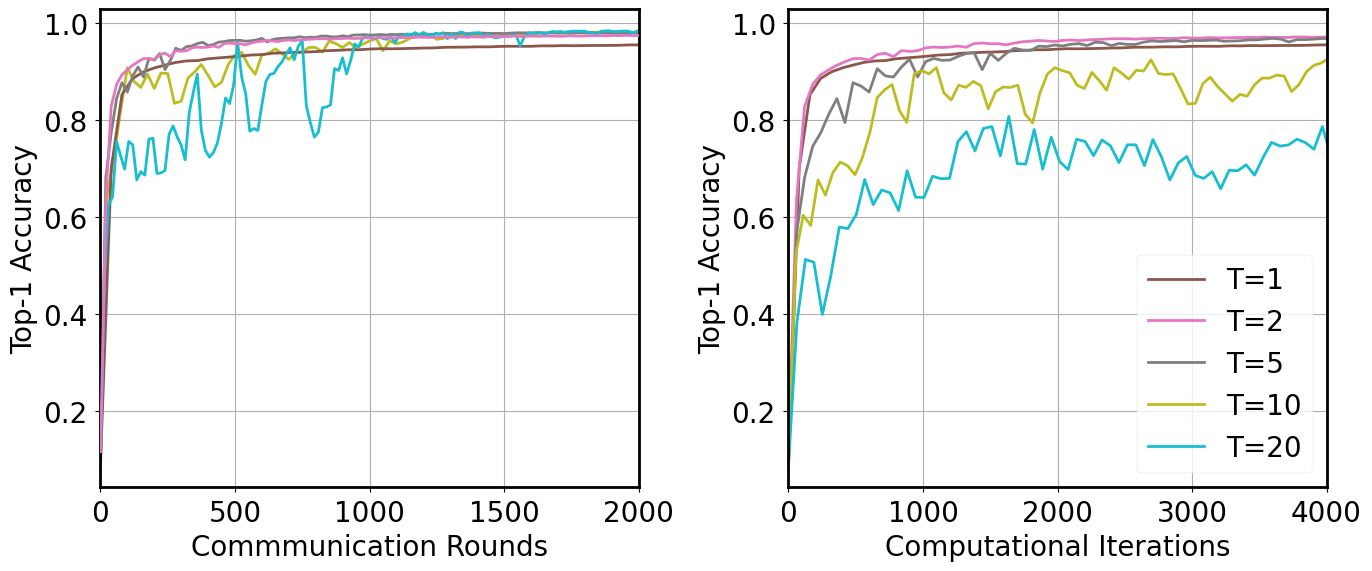

In [4]:
result2_dir="../results/2024-07-24_14-00_dist_mnist_PAPER"
result2_dir="../results/2024-09-06_17-02_dist_mnist_quant_sonata_iter"

# result_dir="../results_paper/2024-09-04_19-29_dist_mnist_iter" #lr=0.005
# result_dir="../results_paper/2024-09-05_20-35_dist_mnist_iter_refine" # lr=0.001
# result_dir="../results_paper/2024-09-09_21-21_dist_mnist_iter_compare" 
result_dir="../results_paper/2024-09-10_13-54_dist_mnist_iter_compare" # lr adjust
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, axs= plt.subplots(1, 2, figsize=(14, 6),tight_layout=True)
ax=axs[1]
iter_1=torch.load(os.path.join(result_dir, "sonata_iter1_results.pt"), map_location=torch.device("cpu"))
iter_2=torch.load(os.path.join(result2_dir, "sonata_results.pt"), map_location=torch.device("cpu"))
iter_5=torch.load(os.path.join(result_dir, "sonata_iter5_results.pt"), map_location=torch.device("cpu"))
iter_10=torch.load(os.path.join(result_dir, "sonata_iter10_results.pt"), map_location=torch.device("cpu"))
iter_20=torch.load(os.path.join(result_dir, "sonata_iter20_results.pt"), map_location=torch.device("cpu"))
comp_times_1=(np.array(iter_1["forward_pass_count"])-64)/64
mean_acc_1=torch.mean(torch.stack(iter_1["top1_accuracy"]), dim=1)
comp_times_2=(np.array(iter_2["forward_pass_count"])-64)/64
mean_acc_2=torch.mean(torch.stack(iter_2["top1_accuracy"]), dim=1)
comp_times_5=(np.array(iter_5["forward_pass_count"])-64)/64
mean_acc_5=torch.mean(torch.stack(iter_5["top1_accuracy"]), dim=1)
comp_times_10=(np.array(iter_10["forward_pass_count"])-64)/64
mean_acc_10=torch.mean(torch.stack(iter_10["top1_accuracy"]), dim=1)
comp_times_20=(np.array(iter_20["forward_pass_count"])-64)/64
mean_acc_20=torch.mean(torch.stack(iter_20["top1_accuracy"]), dim=1)
step=1
ax.plot(comp_times_1[::step], mean_acc_1[::step], label="T=1",color=default_colors[5],linewidth=2)
ax.plot(comp_times_2[::step], mean_acc_2[::step], label="T=2",color=default_colors[6],linewidth=2)
ax.plot(comp_times_5[::step], mean_acc_5[::step], label="T=5",color=default_colors[7],linewidth=2)
ax.plot(comp_times_10[::step], mean_acc_10[::step], label="T=10",color=default_colors[8],linewidth=2)
ax.plot(comp_times_20[::step], mean_acc_20[::step], label="T=20",color=default_colors[9],linewidth=2)
ax.set_xlim(0,4000)
ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.grid()
ax.set_ylabel("Top-1 Accuracy",fontsize=20)
ax.set_xlabel("Computational Iterations",fontsize=20)
ax.legend(loc="lower right",fontsize=20)
ax2=axs[0]
t10=np.arange(mean_acc_10.shape[0]) * 5
t20=np.arange(mean_acc_20.shape[0]) * 3
t5=np.arange(mean_acc_5.shape[0]) * 10
step=5
step5=2
ax2.plot(np.arange(mean_acc_1.shape[0]) * 40,mean_acc_1,color=default_colors[5],linewidth=2, label="T=1")
ax2.plot(np.arange(mean_acc_2.shape[0]) * 20,mean_acc_2,color=default_colors[6],zorder=3,linewidth=2,label="T=2")
ax2.plot(t5[::step5],mean_acc_5[::step5],color=default_colors[7],linewidth=2,label="T=5")
ax2.plot(t10[::step],mean_acc_10[::step],color=default_colors[8],zorder=1,linewidth=2,label="T=10")
ax2.plot(t20[::step],mean_acc_20[::step],color=default_colors[9],zorder=2,linewidth=2,label="T=20")
ax2.set_xlabel("Commmunication Rounds",fontsize=20)
ax2.set_ylabel("Top-1 Accuracy",fontsize=20)

ax2.xaxis.set_major_locator(MultipleLocator(500))
# 设置x轴刻度标签的字体大小
axs[0].tick_params(axis='x', labelsize=20)
axs[1].tick_params(axis='x', labelsize=20)

# 设置y轴刻度标签的字体大小
axs[0].tick_params(axis='y', labelsize=20)
axs[1].tick_params(axis='y', labelsize=20)
ax2.grid()
ax2.set_xlim(0,2000)
# 对每个子图加边框
for ax_i in axs:
    for spine in ax_i.spines.values():
        spine.set_linewidth(2)  # 设置边框线宽为2
        spine.set_edgecolor('black')  # 设置边框颜色为黑色

In [5]:
fig.savefig("T_compare.pdf",dpi=800)

In [7]:
print(plt.style.available)
dinno_color="darkorange"
dsgt_color="seagreen"
dsgd_color="slateblue"
sonata_color="crimson"
sonata_color2="c"
randcom_color="blue"
cent_color="indigo"
solo_color="cornflowerblue"

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


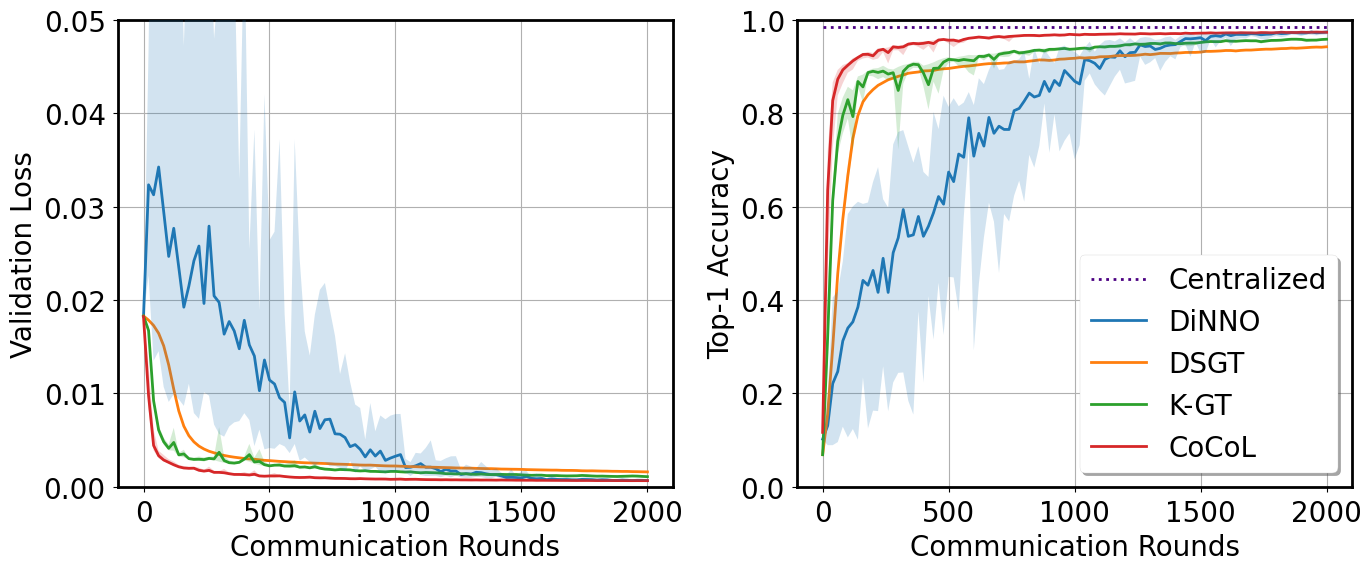

In [22]:
result_dir="../results/2024-07-24_14-00_dist_mnist_PAPER"
dinno_dir="../results/2024-05-22_18-48_dist_mnist_PAPER"
# sonata_dir="../results/2024-05-29_16-21_dist_mnist_PAPER"
# randcom_dir="../results/2024-05-23_14-21_MNIST_RANDCOM"
# dsgt_dir="../results/2024-05-29_15-29_dist_mnist_PAPER"
# sonata_cta_dir="../results/2024-05-29_21-53_dist_mnist_PAPER"
cy_dinno = torch.load(os.path.join(dinno_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
cy_dsgt = torch.load(os.path.join(result_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
cy_kgt = torch.load(os.path.join(result_dir, "kgt_results.pt"), map_location=torch.device("cpu"))
cy_sonata_atc=torch.load(os.path.join(result_dir, "sonata_results.pt"), map_location=torch.device("cpu"))

cy_sonata_atc=iter_2
cy_aca = torch.stack(cy_dinno["top1_accuracy"]) 
cy_acb = torch.stack(cy_dsgt["top1_accuracy"]) 
cy_acc = torch.stack(cy_kgt["top1_accuracy"][:101]) 
cy_acd=torch.stack(cy_sonata_atc["top1_accuracy"])

plt.style.use('seaborn-v0_8-paper')  # 更改图表风格

fig, ax = plt.subplots(1, 2, figsize=(14, 6),tight_layout=True)
# 对每个子图加边框
for ax_i in ax:
    for spine in ax_i.spines.values():
        spine.set_linewidth(2)  # 设置边框线宽为2
        spine.set_edgecolor('black')  # 设置边框颜色为黑色
t = torch.arange(cy_aca.shape[0]) * 20
cent_acc = 0.985
ax[1].plot(t, cent_acc * torch.ones_like(t), c=cent_color,
    linewidth=2, linestyle=":", label="Centralized")

ax[1].plot(t, torch.mean(cy_aca, dim=1), linewidth=2, label="DiNNO")
ax[1].fill_between(t, torch.amax(cy_aca, dim=1), torch.amin(cy_aca, dim=1),
     alpha=0.2, zorder=3)

ax[1].plot(t, torch.mean(cy_acb, dim=1),linewidth=2, label="DSGT")
ax[1].fill_between(t, torch.amax(cy_acb, dim=1), torch.amin(cy_acb, dim=1), alpha=0.2, zorder=1)

ax[1].plot(t, torch.mean(cy_acc, dim=1), linewidth=2, label="K-GT")
ax[1].fill_between(t, torch.amax(cy_acc, dim=1), torch.amin(cy_acc, dim=1), alpha=0.2, zorder=2)

ax[1].plot(t, torch.mean(cy_acd, dim=1),  linewidth=2, label="CoCoL")
ax[1].fill_between(t, torch.amax(cy_acd, dim=1), torch.amin(cy_acd, dim=1),
  alpha=0.2, zorder=4)

ax[1].set_ylim((0.0, 1.0))
ax[1].set_xlabel("Communication Rounds",fontsize=20)
ax[1].set_ylabel("Top-1 Accuracy",fontsize=20)
# fig.suptitle("Ring Graph",fontsize=25)
ax[1].grid(zorder=0)
ax[0].set_ylim((0.0, 0.05))

va_aca=torch.stack(cy_dinno["validation_loss"])
va_acb=torch.stack(cy_dsgt["validation_loss"])
va_acc=torch.stack(cy_kgt["validation_loss"][:101])
va_acd=torch.stack(cy_sonata_atc["validation_loss"])
ax[0].plot(t, torch.mean(va_aca, dim=1), linewidth=2, label="DiNNO")
ax[0].fill_between(t, torch.amax(va_aca, dim=1), torch.amin(va_aca, dim=1),
     alpha=0.2, zorder=3)
ax[0].plot(t, torch.mean(va_acb, dim=1), linewidth=2, label="DSGT")
ax[0].fill_between(t, torch.amax(va_acb, dim=1), torch.amin(va_acb, dim=1), alpha=0.2, zorder=1)
ax[0].plot(t, torch.mean(va_acc, dim=1), linewidth=2, label="K-GT")
ax[0].fill_between(t, torch.amax(va_acc, dim=1), torch.amin(va_acc, dim=1), alpha=0.2, zorder=2)
ax[0].plot(t, torch.mean(va_acd, dim=1), linewidth=2, label="CoCoL")
ax[0].fill_between(t, torch.amax(va_acd, dim=1), torch.amin(va_acd, dim=1),
  alpha=0.2, zorder=4)
ax[1].legend(fontsize=20,shadow=True,frameon=True)
ax[0].set_xlabel("Communication Rounds",fontsize=20)
ax[0].set_ylabel("Validation Loss",fontsize=20)
ax[0].grid(zorder=0)
# 设置x轴的刻度间隔为500
ax[0].xaxis.set_major_locator(MultipleLocator(500))
ax[1].xaxis.set_major_locator(MultipleLocator(500))
ax[1].yaxis.set_major_locator(MultipleLocator(0.2))
# 设置x轴刻度标签的字体大小
ax[0].tick_params(axis='x', labelsize=20)
ax[1].tick_params(axis='x', labelsize=20)

# 设置y轴刻度标签的字体大小
ax[0].tick_params(axis='y', labelsize=20)
ax[1].tick_params(axis='y', labelsize=20)
# fig.savefig("ring_graph.png", dpi=1000)
fig.savefig("ring_graph.pdf", dpi=800)



In [1]:
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
co_dir = "../results/2021-09-07_21-01_dist_mnist_complete"
cy_dir = "../results/2021-09-05_14-27_dist_mnist_v3"
r3_dir = "../results/2021-09-07_20-11_dist_mnist_random3"
r8_dir = "../results/2021-09-07_19-01_dist_mnist_random8"
solo_dir  = "../results/2021-09-04_16-01_dist_mnist_v3"

co_dinno = torch.load(os.path.join(co_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
co_dsgt = torch.load(os.path.join(co_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
co_dsgd = torch.load(os.path.join(co_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

cy_dinno = torch.load(os.path.join(cy_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
cy_dsgt = torch.load(os.path.join(cy_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
cy_dsgd = torch.load(os.path.join(cy_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

r3_dinno = torch.load(os.path.join(r3_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
r3_dsgt = torch.load(os.path.join(r3_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
r3_dsgd = torch.load(os.path.join(r3_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

r8_dinno = torch.load(os.path.join(r8_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
r8_dsgt = torch.load(os.path.join(r8_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
r8_dsgd = torch.load(os.path.join(r8_dir, "dsgd_results.pt"), map_location=torch.device("cpu"))

results_solo = torch.load(os.path.join(solo_dir, "solo_results.pt"), map_location=torch.device("cpu"))

In [3]:
co_G = nx.read_gpickle(os.path.join(co_dir, "graph.gpickle"))
co_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(co_G)
cy_G = nx.read_gpickle(os.path.join(cy_dir, "graph.gpickle"))
cy_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(cy_G)
r3_G = nx.read_gpickle(os.path.join(r3_dir, "graph.gpickle"))
r3_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(r3_G)
r8_G = nx.read_gpickle(os.path.join(r8_dir, "graph.gpickle"))
r8_fied = nx.linalg.algebraicconnectivity.algebraic_connectivity(r8_G)

In [2]:
def plot_vals(ax, aca, acb, acc, results_solo, title):
    t = torch.arange(aca.shape[0]) * 20
    cent_acc = 0.985
    ax.plot(t, cent_acc * torch.ones_like(t), c=cent_color,
        linewidth=2, linestyle=":", label="Centralized")
    
    for i in range(9):
        ax.plot(t, results_solo[i]["validation_accuracy"] * np.ones_like(t),
            linewidth=2, color=solo_color, linestyle=":")
    ax.plot(t, results_solo[9]["validation_accuracy"] * np.ones_like(t),
        linewidth=2, color=solo_color, label="Individual", linestyle=":")
    
    ax.plot(t, torch.mean(aca, dim=1), c=dinno_color, linewidth=2, label="DiNNO")
    ax.fill_between(t, torch.amax(aca, dim=1), torch.amin(aca, dim=1),
        color=dinno_color, alpha=0.5, zorder=3)
    
    ax.plot(t, torch.mean(acb, dim=1), c=dsgt_color, linewidth=2, label="DSGT")
    ax.fill_between(t, torch.amax(acb, dim=1), torch.amin(acb, dim=1),
        color=dsgt_color, alpha=0.5, zorder=2)
    
    ax.plot(t, torch.mean(acc, dim=1), c=dsgd_color, linewidth=2, label="DSGD")
    ax.fill_between(t, torch.amax(acc, dim=1), torch.amin(acc, dim=1),
        color=dsgd_color, alpha=0.5, zorder=1)
    
    ax.set_ylim((0.0, 1.0))
    ax.set_title(title)
    ax.set_xlabel("Communication Round")
    ax.grid(zorder=0)

    

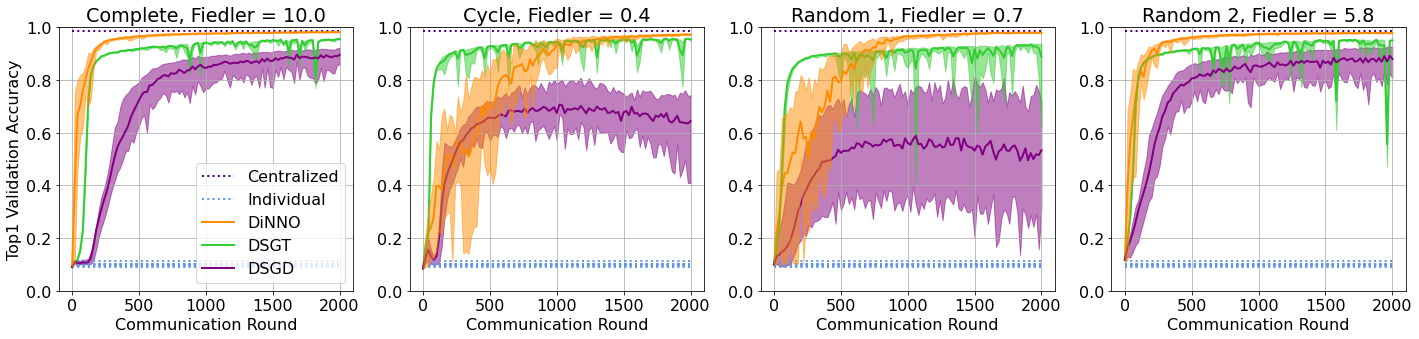

In [5]:
dinno_color="darkorange"
dsgt_color="limegreen"
dsgd_color="purple"
cent_color="indigo"
solo_color="cornflowerblue"

(fig, axs) = plt.subplots(ncols=4, figsize=(20, 5), tight_layout=True)

co_aca = torch.stack(co_dinno["top1_accuracy"]) 
co_acb = torch.stack(co_dsgt["top1_accuracy"]) 
co_acc = torch.stack(co_dsgd["top1_accuracy"]) 

cy_aca = torch.stack(cy_dinno["top1_accuracy"]) 
cy_acb = torch.stack(cy_dsgt["top1_accuracy"]) 
cy_acc = torch.stack(cy_dsgd["top1_accuracy"]) 

r3_aca = torch.stack(r3_dinno["top1_accuracy"]) 
r3_acb = torch.stack(r3_dsgt["top1_accuracy"]) 
r3_acc = torch.stack(r3_dsgd["top1_accuracy"]) 

r8_aca = torch.stack(r8_dinno["top1_accuracy"]) 
r8_acb = torch.stack(r8_dsgt["top1_accuracy"]) 
r8_acc = torch.stack(r8_dsgd["top1_accuracy"]) 

title = "Complete, Fiedler = {:.1f}".format(co_fied)
plot_vals(axs[0], co_aca, co_acb, co_acc, results_solo, title)
axs[0].set_ylabel("Top1 Validation Accuracy")
axs[0].legend(loc=4)

title = "Cycle, Fiedler = {:.1f}".format(cy_fied)
plot_vals(axs[1], cy_aca, cy_acb, cy_acc, results_solo, title)

title = "Random 1, Fiedler = {:.1f}".format(r3_fied)
plot_vals(axs[2], r3_aca, r3_acb, r3_acc, results_solo, title)

title = "Random 2, Fiedler = {:.1f}".format(r8_fied)
plot_vals(axs[3], r8_aca, r8_acb, r8_acc, results_solo, title)

fig.savefig("mnist_four.png", dpi=1000)

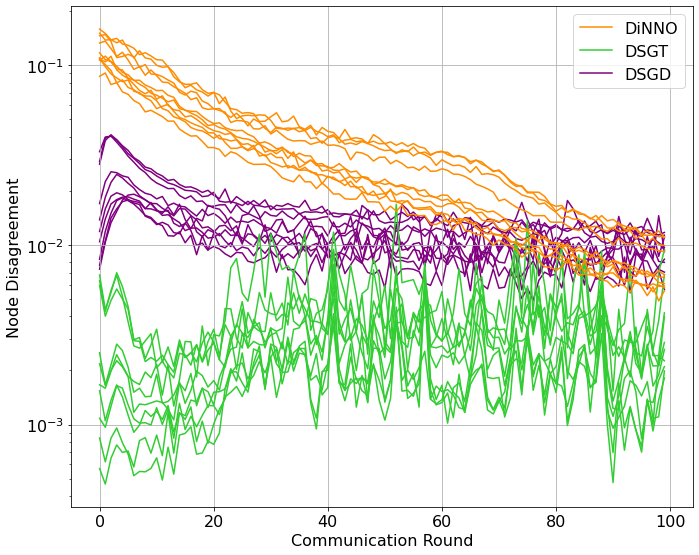

In [6]:
ag_dinno = torch.vstack([v[1].reshape(1, -1) for v in r3_dinno["consensus_error"]])
ag_dsgt = torch.vstack([v[1].reshape(1, -1) for v in r3_dsgt["consensus_error"]])
ag_dsgd = torch.vstack([v[1].reshape(1, -1) for v in r3_dsgd["consensus_error"]])


(fig, ax) = plt.subplots(figsize=(10, 8), tight_layout=True)
ax.plot(ag_dinno[1:, :9], c=dinno_color, zorder=3)
ax.plot(ag_dinno[1:, 9], c=dinno_color, label="DiNNO", zorder=3)

ax.plot(ag_dsgt[1:, :9], c=dsgt_color, zorder=2)
ax.plot(ag_dsgt[1:, 9], c=dsgt_color, label="DSGT", zorder=2)

ax.plot(ag_dsgd[1:, :9], c=dsgd_color, zorder=1)
ax.plot(ag_dsgd[1:, 9], c=dsgd_color, label="DSGD", zorder=1)

ax.set_yscale("log")
ax.grid()
ax.set_xlabel("Communication Round")
ax.set_ylabel("Node Disagreement")
ax.legend(loc=1)
fig.savefig("mnist_agree.svg")

In [33]:
result_dir="../results/2024-07-29_17-16_dist_mnist_Quant_16"
dinno_dir="../results/2024-07-29_17-16_dist_mnist_Quant_16"
sonata_dir="../results/2024-07-29_17-45_dist_mnist_quant_sonata_16"
# randcom_dir="../results/2024-05-23_14-21_MNIST_RANDCOM"
dsgt_dir="../results/2024-07-29_18-09_dist_mnist_dsgt_Quant"
# sonata_cta_dir="../results/2024-05-29_21-53_dist_mnist_PAPER"
cy_dinno = torch.load(os.path.join(result_dir, "dinno_results.pt"), map_location=torch.device("cpu")) 
cy_dsgt = torch.load(os.path.join(dsgt_dir, "dsgt_results.pt"), map_location=torch.device("cpu"))
cy_kgt = torch.load(os.path.join(result_dir, "kgt_results.pt"), map_location=torch.device("cpu"))
cy_sonata_atc=torch.load(os.path.join(sonata_dir, "sonata_results.pt"), map_location=torch.device("cpu"))


cy_aca = torch.stack(cy_dinno["top1_accuracy"]) 
cy_acb = torch.stack(cy_dsgt["top1_accuracy"]) 
cy_acc = torch.stack(cy_kgt["top1_accuracy"]) 
cy_acd=torch.stack(cy_sonata_atc["top1_accuracy"])
mean_aca=torch.mean(cy_aca,dim=1)
mean_acb=torch.mean(cy_acb,dim=1)
mean_acc=torch.mean(cy_acc,dim=1)
mean_acd=torch.mean(cy_acd,dim=1)
t = torch.arange(mean_aca.shape[0]) * 20
print(t[np.argmax(mean_aca>0.95)],t[np.argmax(mean_acb>0.939)],t[np.argmax(mean_acc>0.95)],t[np.argmax(mean_acd>0.95)])


tensor(620) tensor(1940) tensor(800) tensor(320)


In [31]:
print(mean_acb)

tensor([0.1630, 0.2728, 0.4093, 0.5172, 0.6217, 0.7074, 0.7584, 0.7916, 0.8180,
        0.8347, 0.8494, 0.8580, 0.8651, 0.8725, 0.8768, 0.8798, 0.8823, 0.8849,
        0.8875, 0.8908, 0.8921, 0.8935, 0.8957, 0.8969, 0.8983, 0.8990, 0.9005,
        0.9032, 0.9040, 0.9030, 0.9064, 0.9072, 0.9072, 0.9075, 0.9091, 0.9093,
        0.9119, 0.9124, 0.9135, 0.9137, 0.9147, 0.9147, 0.9170, 0.9182, 0.9183,
        0.9199, 0.9180, 0.9203, 0.9201, 0.9223, 0.9225, 0.9219, 0.9242, 0.9243,
        0.9239, 0.9239, 0.9250, 0.9256, 0.9260, 0.9265, 0.9259, 0.9266, 0.9281,
        0.9284, 0.9290, 0.9293, 0.9292, 0.9298, 0.9294, 0.9297, 0.9309, 0.9310,
        0.9318, 0.9326, 0.9315, 0.9322, 0.9329, 0.9332, 0.9330, 0.9346, 0.9339,
        0.9342, 0.9350, 0.9351, 0.9362, 0.9359, 0.9359, 0.9358, 0.9359, 0.9372,
        0.9358, 0.9375, 0.9378, 0.9380, 0.9388, 0.9388, 0.9385, 0.9396, 0.9396,
        0.9396, 0.9397], dtype=torch.float64)
